lIBRARYS

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

In [57]:
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/STUDENT_EXAM.xlsx")

print(df.head())
print(df.shape)
print(df.info())

   Student_id Gender  Study_ho  Attendance_Rate Internet_Access_at_Home  \
0        1001      F        11               58                     YES   
1        1002      F        10               56                     YES   
2        1003      F         5               49                      NO   
3        1004      M         9               57                     YES   
4        1005      F         6               60                      NO   

   Past_Exam_Scores Extracurricular_Activities  Parental_Education_Level  \
0                50                        YES                        12   
1                70                         NO                         5   
2                80                        YES                         9   
3                60                         NO                         7   
4                90                         NO                         3   

   Final_Exam_Score Pass_Fail  
0            100.00      Pass  
1            100.00      Pas

check missing values

In [58]:
print(df.isnull().sum())

Student_id                    0
Gender                        0
Study_ho                      0
Attendance_Rate               0
Internet_Access_at_Home       0
Past_Exam_Scores              0
Extracurricular_Activities    0
Parental_Education_Level      0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64


remove duplicate

In [59]:
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(20, 10)


data type varification

In [60]:
print(df.dtypes)

Student_id                      int64
Gender                         object
Study_ho                        int64
Attendance_Rate                 int64
Internet_Access_at_Home        object
Past_Exam_Scores                int64
Extracurricular_Activities     object
Parental_Education_Level        int64
Final_Exam_Score              float64
Pass_Fail                      object
dtype: object


Encode Categorical Variables

In [61]:
le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Parental_Education_Level',
    'Internet_Access_at_Home',
    'Extracurricular_Activities',
    'Pass_Fail'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

statices

In [62]:
print("Average Study Hours:")
print(df['Study_ho'].mean())

print("Average Attendance Rate:")
print(df['Attendance_Rate'].mean())

print("Average Past Exam Scores:")
print(df['Past_Exam_Scores'].mean())

print("Average Final Exam Score:")
print(df['Final_Exam_Score'].mean())

print("Pass vs Fail Count:")
print(df['Pass_Fail'].value_counts())

print("Gender Distribution:")
print(df['Gender'].value_counts())

Average Study Hours:
8.4
Average Attendance Rate:
70.55
Average Past Exam Scores:
64.7
Average Final Exam Score:
93.1335
Pass vs Fail Count:
Pass_Fail
0    20
Name: count, dtype: int64
Gender Distribution:
Gender
0    12
1     8
Name: count, dtype: int64


Student Performance Analysis

Pass vs Fail

In [63]:
print(df.groupby('Pass_Fail').mean(numeric_only=True))

           Student_id  Gender  Study_ho  Attendance_Rate  \
Pass_Fail                                                  
0              1010.5     0.4       8.4            70.55   

           Internet_Access_at_Home  Past_Exam_Scores  \
Pass_Fail                                              
0                              0.6              64.7   

           Extracurricular_Activities  Parental_Education_Level  \
Pass_Fail                                                         
0                                 0.4                      5.75   

           Final_Exam_Score  
Pass_Fail                    
0                   93.1335  


Internet Access Impact

In [12]:
print(pd.crosstab(
    df['Internet_Access_at_Home'],
    df['Pass_Fail']
))

Pass_Fail                 0
Internet_Access_at_Home    
0                         8
1                        12


Extracurricular Activities Impact

In [13]:
print(pd.crosstab(
    df['Extracurricular_Activities'],
    df['Pass_Fail']
))

Pass_Fail                    0
Extracurricular_Activities    
0                           12
1                            8


Group Based Analysis

Study Hours vs Pass/Fail

In [15]:
print(
    df.groupby('Pass_Fail')['Study_ho'].mean()
)

Pass_Fail
0    8.4
Name: Study_ho, dtype: float64


Attendance vs Pass/Fail

In [16]:
print(
    df.groupby('Pass_Fail')['Attendance_Rate'].mean()
)

Pass_Fail
0    70.55
Name: Attendance_Rate, dtype: float64


Past Score vs Pass/Fail

In [17]:
print(
    df.groupby('Pass_Fail')['Past_Exam_Scores'].mean()
)

Pass_Fail
0    64.7
Name: Past_Exam_Scores, dtype: float64


Gender vs Pass Rate

In [18]:
print(
    pd.crosstab(df['Gender'], df['Pass_Fail'])
)

Pass_Fail   0
Gender       
0          12
1           8


Relationship Analysis


Correlation Matrix

In [19]:
correlation = df.corr(numeric_only=True)

print(correlation)

                            Student_id    Gender  Study_ho  Attendance_Rate  \
Student_id                    1.000000  0.035400  0.035881         0.464331   
Gender                        0.035400  1.000000 -0.050680        -0.190713   
Study_ho                      0.035881 -0.050680  1.000000         0.184478   
Attendance_Rate               0.464331 -0.190713  0.184478         1.000000   
Internet_Access_at_Home      -0.017700  0.250000  0.008447        -0.150687   
Past_Exam_Scores             -0.046495  0.062388 -0.596419        -0.218898   
Extracurricular_Activities    0.035400 -0.041667  0.287188        -0.202486   
Parental_Education_Level     -0.041948 -0.256014 -0.133456        -0.245159   
Final_Exam_Score             -0.696760  0.047173  0.021500        -0.337387   
Pass_Fail                          NaN       NaN       NaN              NaN   

                            Internet_Access_at_Home  Past_Exam_Scores  \
Student_id                                -0.017700      

Visualizations

Pass vs Fail Distribution

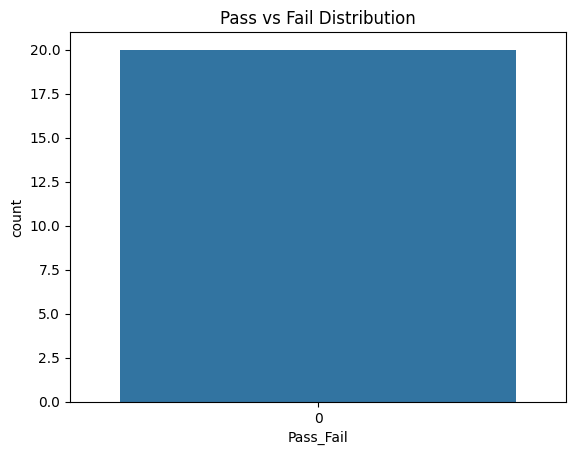

In [20]:
sns.countplot(x='Pass_Fail', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

Gender Distribution

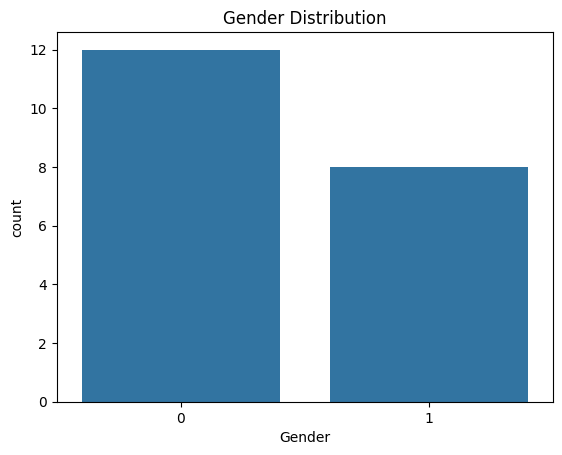

In [21]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

Internet Access Distribution

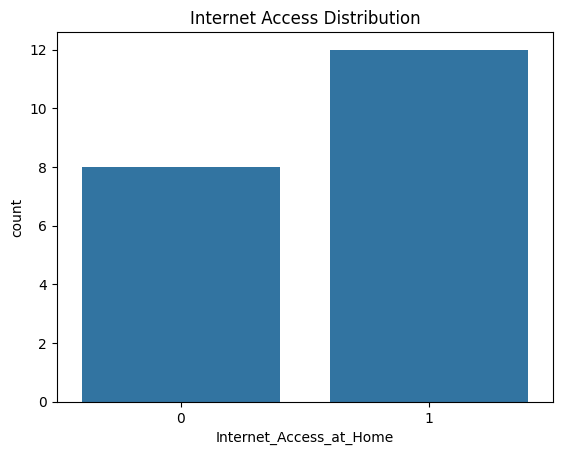

In [22]:
sns.countplot(x='Internet_Access_at_Home', data=df)
plt.title("Internet Access Distribution")
plt.show()

Study Hours Histogram

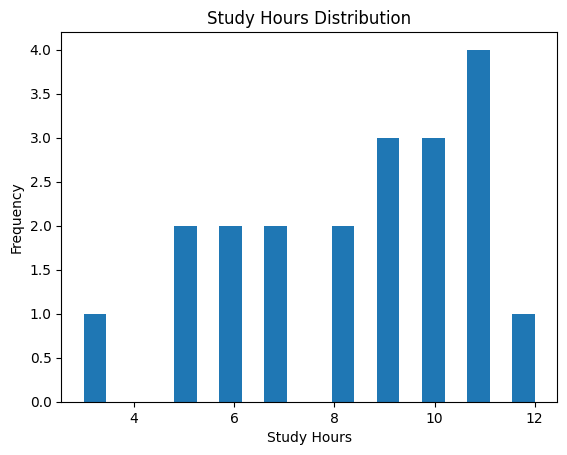

In [24]:
plt.hist(df['Study_ho'], bins=20)

plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")

plt.show()

Attendance Histogram

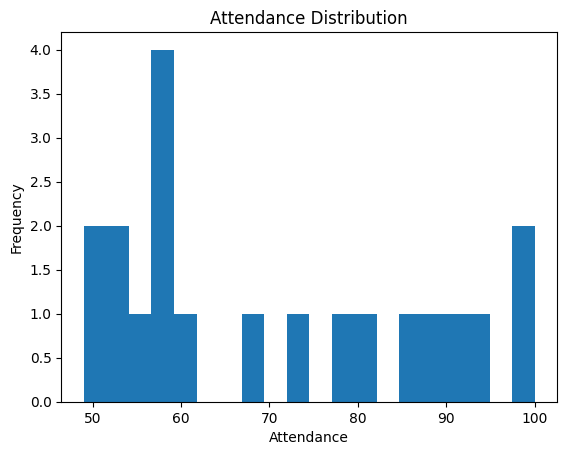

In [25]:
plt.hist(df['Attendance_Rate'], bins=20)

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")

plt.show()

Final Score Histogram

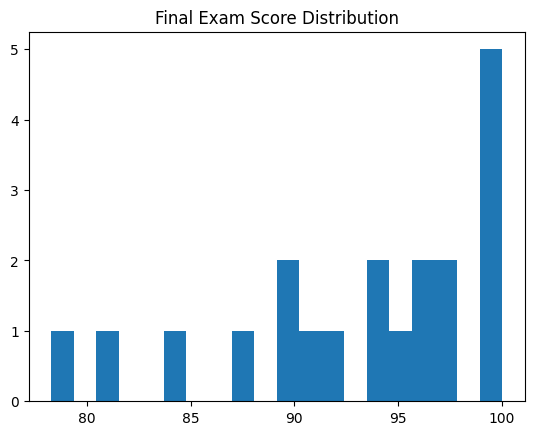

In [26]:
plt.hist(df['Final_Exam_Score'], bins=20)

plt.title("Final Exam Score Distribution")
plt.show()

Study Hours vs Final Score

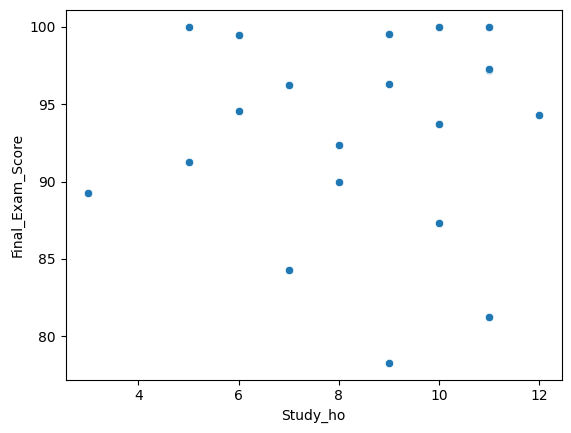

In [28]:
sns.scatterplot(
    x='Study_ho',
    y='Final_Exam_Score',
    data=df
)

plt.show()

Attendance vs Final Score

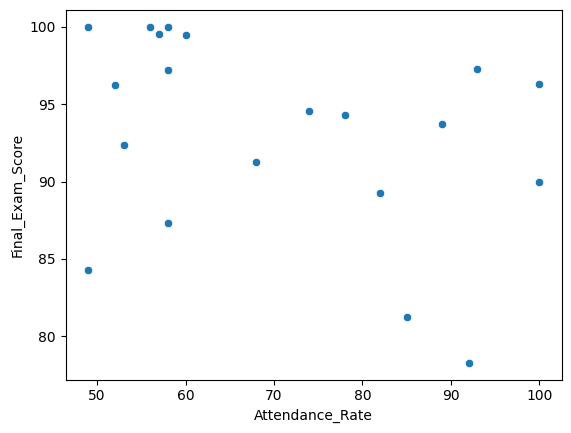

In [29]:
sns.scatterplot(
    x='Attendance_Rate',
    y='Final_Exam_Score',
    data=df
)

plt.show()

Box Plot

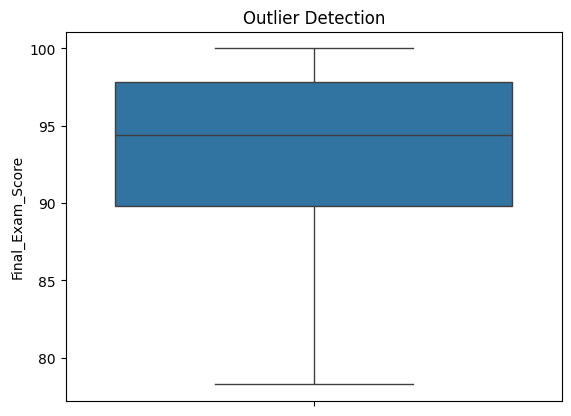

In [30]:
sns.boxplot(y=df['Final_Exam_Score'])

plt.title("Outlier Detection")
plt.show()

Heatmap

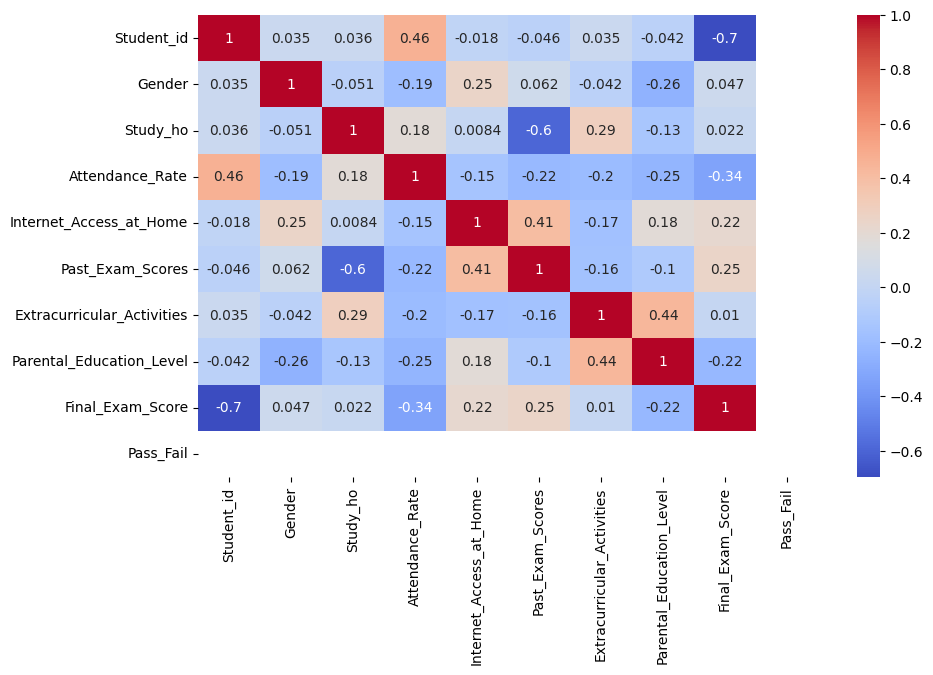

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.show()

Risk Analysis

In [33]:
def risk_category(row):

    if (
        row['Attendance_Rate'] < 60 and
        row['Study_ho'] < 10 and
        row['Past_Exam_Scores'] < 50
    ):
        return "High Risk"

    elif (
        row['Attendance_Rate'] < 75
    ):
        return "Medium Risk"

    else:
        return "Low Risk"

df['Risk_Category'] = df.apply(
    risk_category,
    axis=1
)

print(df['Risk_Category'].value_counts())

Risk_Category
Medium Risk    12
Low Risk        8
Name: count, dtype: int64


Feature Selection

In [40]:
X = df.drop(
    ['Student_id', 'Final_Exam_Score', 'Pass_Fail', 'Risk_Category'],
    axis=1
)

y = df['Final_Exam_Score']

Feature Scaling

In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


Train Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Prediction

In [47]:
y_pred = model.predict(X_test)


## Model Evaluation

In [48]:
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred):.2f}")


Mean Absolute Error (MAE): 7.11
Mean Squared Error (MSE): 72.73
R-squared (R2): -0.75


## Linear Regression Model

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Prediction

In [44]:
y_pred = model.predict(X_test)


## Model Evaluation

In [45]:
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred):.2f}")


Mean Absolute Error (MAE): 7.11
Mean Squared Error (MSE): 72.73
R-squared (R2): -0.75


Dashboard

In [54]:
!pip install streamlit
import streamlit as st
import pandas as pd
import plotly.express as px

# Removed: df = pd.read_csv("student_performance_prediction.csv") as df is already loaded

st.title("Student Exam Pass Prediction Dashboard")

fig1 = px.histogram(
    df,
    x='Pass_Fail'
)

st.plotly_chart(fig1)

fig2 = px.scatter(
    df,
    x='Study_ho', # Corrected column name from 'Study_Hours_per_Week'
    y='Final_Exam_Score',
    color='Pass_Fail'
)

st.plotly_chart(fig2)

fig3 = px.box(
    df,
    x='Pass_Fail',
    y='Attendance_Rate'
)

st.plotly_chart(fig3)

st.dataframe(df.head())

2026-06-12 13:25:39.855 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:25:39.957 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-12 13:25:39.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:25:39.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:25:40.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:25:40.478 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:25:40.479 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:25:40.480 Thread 'MainThread': mi

DeltaGenerator()